In [3]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# default evaluation
ranks = [1, 2, 4, 8, 16, 32]

time_rank1 = 854.4943
acc_rank1 = [42.50, 43.00, 41.50, 40.50, 43.50]
time_rank2 = 887.7424
acc_rank2 = [44.00, 41.90, 46.00, 42.80, 43.00]
time_rank4 = 893.8525
acc_rank4 = [42.10, 39.90, 42.70, 43.40, 42.80]
time_rank8 = 932.3201
acc_rank8 = [41.40, 43.20, 40.90, 42.80, 45.70]
time_rank16 = 955.5072
acc_rank16 = [41.20, 43.20, 44.00, 44.20, 43.70]
time_rank32 = 993.1090
acc_rank32 = [40.80, 42.40, 42.30, 41.90, 43.90]

ranks = [1, 2, 4, 8, 16, 32]

times = [854.4943, 887.7424, 893.8525, 932.3201, 955.5072, 993.1090]

accs = [
    [42.50, 43.00, 41.50, 40.50, 43.50],
    [44.00, 41.90, 46.00, 42.80, 43.00],
    [42.10, 39.90, 42.70, 43.40, 42.80],
    [41.40, 43.20, 40.90, 42.80, 45.70],
    [41.20, 43.20, 44.00, 44.20, 43.70],
    [40.80, 42.40, 42.30, 41.90, 43.90]
]

avg_acc = [np.mean(a) for a in accs]
efficiency = [1000/t for t in times]

# sort by rank (already sorted, but keep for safety)
order = np.argsort(ranks)
ranks = np.array(ranks)[order]
avg_acc = np.array(avg_acc)[order]
efficiency = np.array(efficiency)[order]


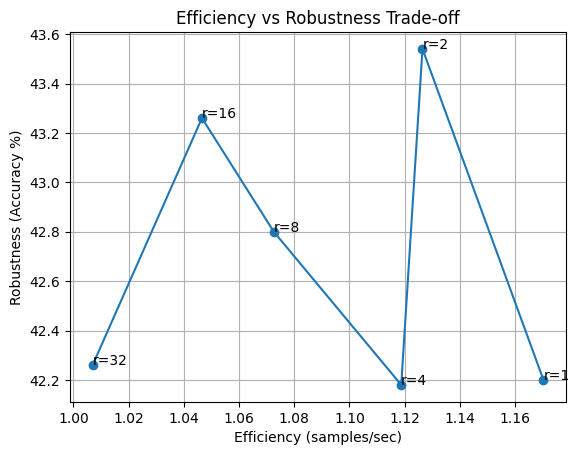

In [16]:
plt.figure()

# line + points
plt.plot(efficiency, avg_acc, marker='o')

# labels
for i, r in enumerate(ranks):
    plt.text(efficiency[i], avg_acc[i], f"r={r}")

plt.xlabel("Efficiency (samples/sec)")
plt.ylabel("Robustness (Accuracy %)")
plt.title("Efficiency vs Robustness Trade-off")

plt.grid(True)
plt.show()

In [35]:
# OOD test
acc_depth4 = [95.20, 94.70, 95.40, 95.20, 95.30, 95.40]
acc_depth6 = [43.40, 43.60, 43.50, 43.70, 43.60, 44.10]
acc_depth8 = [42.50, 42.60, 42.60, 42.60, 42.70, 42.50]
acc_range50 = [43.10, 47.40, 50.30, 50.00, 50.30, 50.30]
acc_range100 = [16.80, 20.30, 21.50, 21.80, 22.50, 22.20]

psr_depth4 = [96.80, 96.80, 96.80, 96.80, 96.80, 96.80]
psr_depth6 = [71.70, 72.40, 72.70, 75.40, 75.20, 76.50]
psr_depth8 = [52.70, 53.50, 53.60, 55.30, 54.80, 54.20]
psr_range50 = [95.50, 95.60, 95.30, 95.50, 95.20, 95.50]
psr_range100 = [94.10, 93.90, 93.60, 93.90, 94.00, 93.80]

depths = [4, 6, 8]
acc_depth = [95.40, 43.70, 42.60]  # rank 8

ranges = [20, 50, 100]
acc_range = [95.40, 50.00, 21.80]  # rank 8

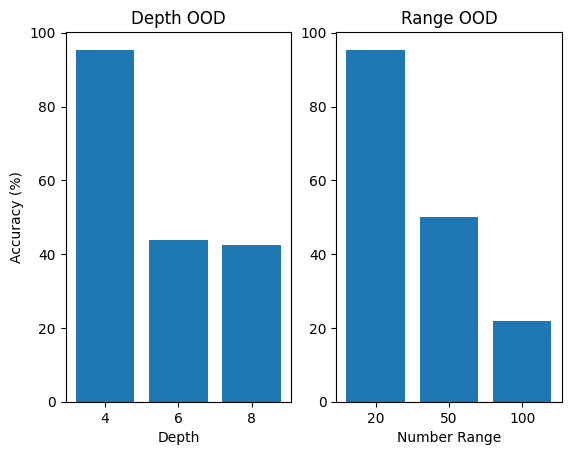

In [27]:
fig, axes = plt.subplots(1, 2)

# Depth
axes[0].bar([str(d) for d in depths], acc_depth)
axes[0].set_title("Depth OOD")
axes[0].set_xlabel("Depth")
axes[0].set_ylabel("Accuracy (%)")

# Range
axes[1].bar([str(r) for r in ranges], acc_range)
axes[1].set_title("Range OOD")
axes[1].set_xlabel("Number Range")

plt.show()

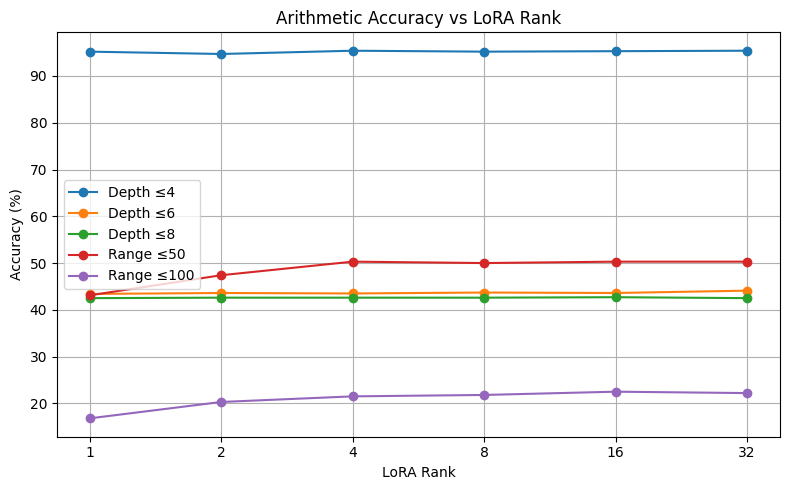

In [30]:
plt.figure(figsize=(8,5))

plt.plot(ranks, acc_depth4, marker='o', label='Depth ≤4')
plt.plot(ranks, acc_depth6, marker='o', label='Depth ≤6')
plt.plot(ranks, acc_depth8, marker='o', label='Depth ≤8')
plt.plot(ranks, acc_range50, marker='o', label='Range ≤50')
plt.plot(ranks, acc_range100, marker='o', label='Range ≤100')

plt.xscale('log', base=2)
plt.xticks(ranks, ranks)

plt.xlabel("LoRA Rank")
plt.ylabel("Accuracy (%)")
plt.title("Arithmetic Accuracy vs LoRA Rank")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

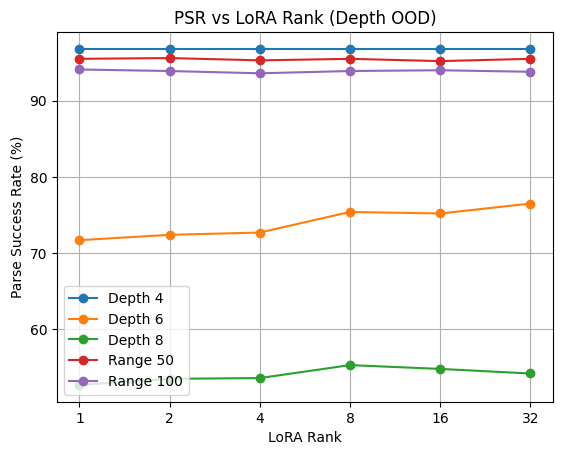

In [36]:
plt.figure()

plt.plot(ranks, psr_depth4, marker='o', label="Depth 4")
plt.plot(ranks, psr_depth6, marker='o', label="Depth 6")
plt.plot(ranks, psr_depth8, marker='o', label="Depth 8")
plt.plot(ranks, psr_range50, marker='o', label="Range 50")
plt.plot(ranks, psr_range100, marker='o', label="Range 100")
plt.xscale('log', base=2)
plt.xticks(ranks, ranks)
plt.xlabel("LoRA Rank")
plt.ylabel("Parse Success Rate (%)")
plt.title("PSR vs LoRA Rank (Depth OOD)")

plt.legend()
plt.grid(True)

plt.show()

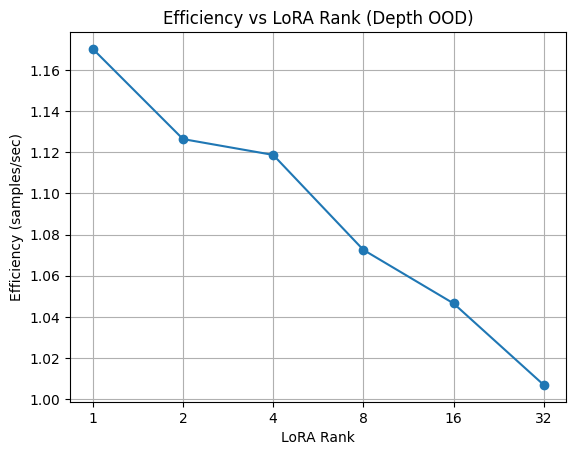

In [40]:
plt.figure()

plt.plot(ranks, efficiency, marker='o')
plt.xscale('log', base=2)
plt.xticks(ranks, ranks)
plt.xlabel("LoRA Rank")
plt.ylabel("Efficiency (samples/sec)")
plt.title("Efficiency vs LoRA Rank (Depth OOD)")

plt.grid(True)
plt.show()